In [1]:
import pandas as pd

# dosyaları oku
main = pd.read_excel("Final2.xlsx")
fifa = pd.read_csv("players19.csv")

# ilk bakış
print("MAIN:")
print(main.head())

print("\nFIFA:")
print(fifa.head())

MAIN:
   Unnamed: 0.1  Unnamed: 0           Player Market value Nation    Pos  \
0             0           0    Kylian Mbappé     €180.00m    FRA     FW   
1             1           1  Raheem Sterling     €128.00m    ENG     FW   
2             2           2           Neymar     €128.00m    BRA  MF,FW   
3             3           3       Sadio Mané     €120.00m    SEN     FW   
4             4           4    Mohamed Salah     €120.00m    EGY     FW   

            Club_x          Leauge   Age    MP  ...   Int   Clr  \
0        Paris S-G          Ligue1  20.0  49.0  ...   7.0   3.0   
1  Manchester City  Premier Leauge  24.0  60.0  ...  27.0  13.0   
2        Paris S-G          Ligue1  27.0  32.0  ...  10.0   2.0   
3        Liverpool  Premier Leauge  27.0  64.0  ...  28.0  11.0   
4        Liverpool  Premier Leauge  27.0  65.0  ...  12.0   5.0   

   Passes Completed  Passes Attempted   Cmp%  Touches  Succ_y    Att  Succ%  \
0            1152.0            1494.0  77.11   2120.0   132.0

In [3]:
# kolon isimlerini temizle
main.columns = main.columns.str.strip().str.lower()
fifa.columns = fifa.columns.str.strip().str.lower()

print(main.columns)
print(fifa.columns)

Index(['unnamed: 0.1', 'unnamed: 0', 'player', 'market value', 'nation', 'pos',
       'club_x', 'leauge', 'age', 'mp', 'starts', 'min', 'gls', 'ast', 'pk_x',
       'pkatt_x', 'crdy', 'crdr', 'gls90', 'ast90', 'g+a', 'gls+ast', 'pk',
       'pkatt', 'sh', 'sot', 'fk', 'sot%', 'sh/90', 'sot/90', 'g/sh', 'g/sot',
       'tackle', 'tacklew', 'takled', 'tkl%', 'press', 'succ_x', '%', 'blocks',
       'shotb', 'passb', 'int', 'clr', 'passes completed', 'passes attempted',
       'cmp%', 'touches', 'succ_y', 'att', 'succ%', '#pl'],
      dtype='object')
Index(['sofifa_id', 'player_url', 'short_name', 'long_name', 'age', 'dob',
       'height_cm', 'weight_kg', 'nationality', 'club_name',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=106)


In [4]:
# main'deki isim kolonu
main["player_name"] = main["player"].astype(str).str.lower().str.strip()

# fifa'daki isim kolonu (short_name kullanıyoruz)
fifa["player_name"] = fifa["short_name"].astype(str).str.lower().str.strip()

# kontrol edelim
print(main["player_name"].head())
print(fifa["player_name"].head())

0      kylian mbappé
1    raheem sterling
2             neymar
3         sadio mané
4      mohamed salah
Name: player_name, dtype: object
0    cristiano ronaldo
1             l. messi
2               neymar
3               de gea
4         k. de bruyne
Name: player_name, dtype: object


In [5]:
# fifa'da long_name kullanalım
fifa["player_name"] = fifa["long_name"].astype(str).str.lower().str.strip()

# tekrar kontrol
print(main["player_name"].head(10))
print(fifa["player_name"].head(10))

0             kylian mbappé
1           raheem sterling
2                    neymar
3                sadio mané
4             mohamed salah
5                harry kane
6           kevin de bruyne
7              jadon sancho
8              lionel messi
9    trent alexander-arnold
Name: player_name, dtype: object
0    cristiano ronaldo dos santos aveiro
1         lionel andrés messi cuccittini
2          neymar da silva santos júnior
3                  david de gea quintana
4                        kevin de bruyne
5                    sergio ramos garcía
6               luis alberto suárez díaz
7                            luka modrić
8                            eden hazard
9                              jan oblak
Name: player_name, dtype: object


In [6]:
# sadece ilk iki kelimeyi al (isim + soyisim gibi)
fifa["player_name"] = fifa["player_name"].apply(lambda x: " ".join(x.split()[:2]))

# kontrol
print(main["player_name"].head(10))
print(fifa["player_name"].head(10))

0             kylian mbappé
1           raheem sterling
2                    neymar
3                sadio mané
4             mohamed salah
5                harry kane
6           kevin de bruyne
7              jadon sancho
8              lionel messi
9    trent alexander-arnold
Name: player_name, dtype: object
0    cristiano ronaldo
1        lionel andrés
2            neymar da
3             david de
4             kevin de
5         sergio ramos
6         luis alberto
7          luka modrić
8          eden hazard
9            jan oblak
Name: player_name, dtype: object


In [7]:
import pandas as pd

df = pd.read_csv("merged_data.csv")
df.head()

,player_name,market value,nation,pos,club_x,leauge,age_x,mp,starts,min,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,sadio mané,€120.00m,SEN,FW,Liverpool,Premier Leauge,27.0,64.0,61.0,5327.0,...,66+3,63+3,63+3,63+3,66+3,63+3,55+3,55+3,55+3,63+3
1,harry kane,€120.00m,ENG,FW,Tottenham,Premier Leauge,26.0,50.0,49.0,4382.0,...,65+3,66+3,66+3,66+3,65+3,62+3,60+3,60+3,60+3,62+3
2,kevin de bruyne,€120.00m,BEL,MF,Manchester City,Premier Leauge,28.0,48.0,38.0,3311.0,...,77+3,77+3,77+3,77+3,77+3,73+3,67+3,67+3,67+3,73+3
3,jadon sancho,€117.00m,ENG,"MF,FW",Dortmund,Bundesliga,19.0,66.0,51.0,4748.0,...,56+1,49+1,49+1,49+1,56+1,52+1,41+1,41+1,41+1,52+1
4,trent alexander-arnold,€99.00m,ENG,DF,Liverpool,Premier Leauge,20.0,60.0,57.0,5174.0,...,77+2,74+2,74+2,74+2,77+2,76+2,72+2,72+2,72+2,76+2


In [8]:
print(df.shape)
print(df.columns)

(244, 155)
Index(['player_name', 'market value', 'nation', 'pos', 'club_x', 'leauge',
       'age_x', 'mp', 'starts', 'min',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=155)


In [9]:
# unnamed kolonları sil
df = df.loc[:, ~df.columns.str.contains('unnamed')]

df.shape

(244, 155)

In [13]:
df = df.loc[:, ~df.columns.str.contains('unnamed', case=False)]

In [10]:
# € ve m kaldır → float yap
df["market value"] = df["market value"].str.replace("€", "")
df["market value"] = df["market value"].str.replace("m", "")
df["market value"] = df["market value"].astype(float)

df["market value"].head()

0    120.0
1    120.0
2    120.0
3    117.0
4     99.0
Name: market value, dtype: float64

In [11]:
# genel istatistik
df["market value"].describe()

count    244.000000
mean      33.147541
std       20.009739
min       16.000000
25%       20.000000
50%       25.250000
75%       40.000000
max      120.000000
Name: market value, dtype: float64

In [12]:
df.groupby("leauge")["market value"].mean().sort_values(ascending=False)

leauge
La Liga           44.464286
Premier Leauge    36.746667
Bundesliga        33.968750
Serie A           27.666667
Ligue1            25.340909
Name: market value, dtype: float64

In [14]:
df.columns

Index(['player_name', 'market value', 'nation', 'pos', 'club_x', 'leauge',
       'age_x', 'mp', 'starts', 'min',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=155)

In [16]:
from scipy.stats import ttest_ind

premier = df[df["leauge"] == "Premier League"]["market value"]
others = df[df["leauge"] != "Premier League"]["market value"]

print("Premier count:", len(premier))
print("Others count:", len(others))

t_stat, p_value = ttest_ind(premier, others, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

Premier count: 0
Others count: 244
t-stat: nan
p-value: nan


In [17]:
df["leauge"].unique()

array(['Premier Leauge', 'Bundesliga', 'La Liga', nan, 'Serie A',
       'Ligue1'], dtype=object)

In [18]:
df["leauge"] = df["leauge"].str.strip()

In [19]:
from scipy.stats import ttest_ind

premier = df[df["leauge"] == "Premier League"]["market value"]
others = df[df["leauge"] != "Premier League"]["market value"]

print("Premier count:", len(premier))
print("Others count:", len(others))

t_stat, p_value = ttest_ind(premier, others, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)


Premier count: 0
Others count: 244
t-stat: nan
p-value: nan


In [20]:
from scipy.stats import ttest_ind

df_test = df.dropna(subset=["league", "market value"]).copy()

premier = df_test[df_test["league"] == "Premier League"]["market value"]
others = df_test[df_test["league"] != "Premier League"]["market value"]

print("Premier count:", len(premier))
print("Others count:", len(others))

t_stat, p_value = ttest_ind(premier, others, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

KeyError: ['league']

In [21]:
print(df.columns)

Index(['player_name', 'market value', 'nation', 'pos', 'club_x', 'leauge',
       'age_x', 'mp', 'starts', 'min',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=155)


In [22]:
df = df.rename(columns={"leauge": "league"})
print(df.columns)

Index(['player_name', 'market value', 'nation', 'pos', 'club_x', 'league',
       'age_x', 'mp', 'starts', 'min',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=155)


In [23]:
from scipy.stats import ttest_ind

df_test = df.dropna(subset=["league", "market value"]).copy()

premier = df_test[df_test["league"] == "Premier League"]["market value"]
others = df_test[df_test["league"] != "Premier League"]["market value"]

print("Premier count:", len(premier))
print("Others count:", len(others))

t_stat, p_value = ttest_ind(premier, others, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

Premier count: 0
Others count: 198
t-stat: nan
p-value: nan


In [24]:
print(df.columns)
print(df["league"].unique())
print(df["league"].value_counts(dropna=False))

Index(['player_name', 'market value', 'nation', 'pos', 'club_x', 'league',
       'age_x', 'mp', 'starts', 'min',
       ...
       'lwb', 'ldm', 'cdm', 'rdm', 'rwb', 'lb', 'lcb', 'cb', 'rcb', 'rb'],
      dtype='object', length=155)
['Premier Leauge' 'Bundesliga' 'La Liga' nan 'Serie A' 'Ligue1']
league
Premier Leauge    75
Bundesliga        48
NaN               46
Serie A           39
Ligue1            22
La Liga           14
Name: count, dtype: int64


In [25]:
df["league"] = df["league"].astype(str).str.strip()
print(df["league"].unique())
print(df["league"].value_counts(dropna=False))

['Premier Leauge' 'Bundesliga' 'La Liga' 'nan' 'Serie A' 'Ligue1']
league
Premier Leauge    75
Bundesliga        48
nan               46
Serie A           39
Ligue1            22
La Liga           14
Name: count, dtype: int64


In [26]:
from scipy.stats import ttest_ind

df_test = df.dropna(subset=["league", "market value"]).copy()

premier = df_test[df_test["league"].str.contains("Premier", case=False, na=False)]["market value"]
others = df_test[~df_test["league"].str.contains("Premier", case=False, na=False)]["market value"]

print("Premier count:", len(premier))
print("Others count:", len(others))

t_stat, p_value = ttest_ind(premier, others, equal_var=False)

print("t-stat:", t_stat)
print("p-value:", p_value)

Premier count: 75
Others count: 169
t-stat: 1.6568460058052306
p-value: 0.10043548671348725


In [27]:
import matplotlib.pyplot as plt

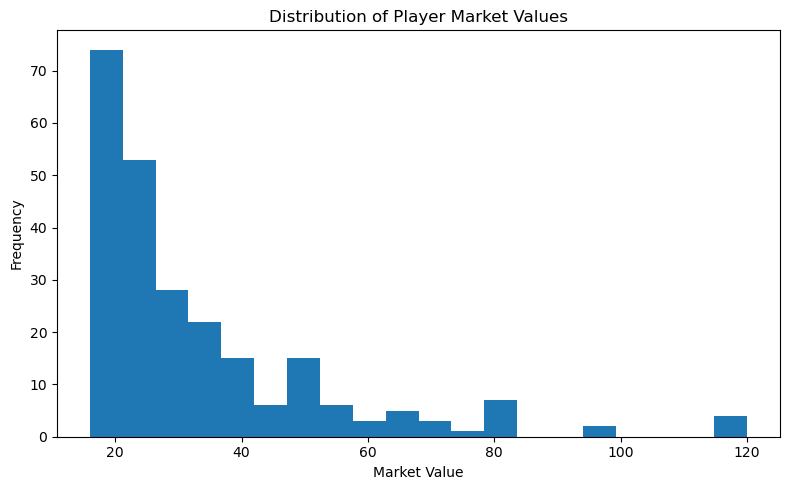

In [28]:
plt.figure(figsize=(8, 5))
plt.hist(df["market value"], bins=20)
plt.xlabel("Market Value")
plt.ylabel("Frequency")
plt.title("Distribution of Player Market Values")
plt.tight_layout()
plt.show()

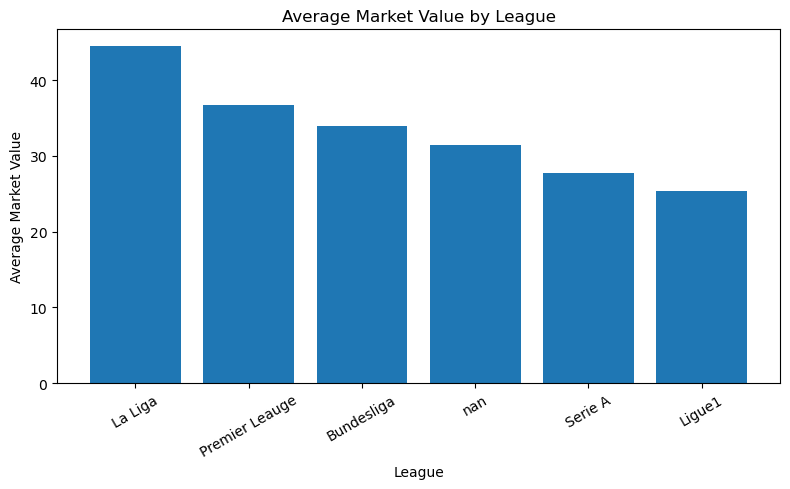

In [29]:
league_means = df.groupby("league")["market value"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(league_means.index, league_means.values)
plt.xlabel("League")
plt.ylabel("Average Market Value")
plt.title("Average Market Value by League")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


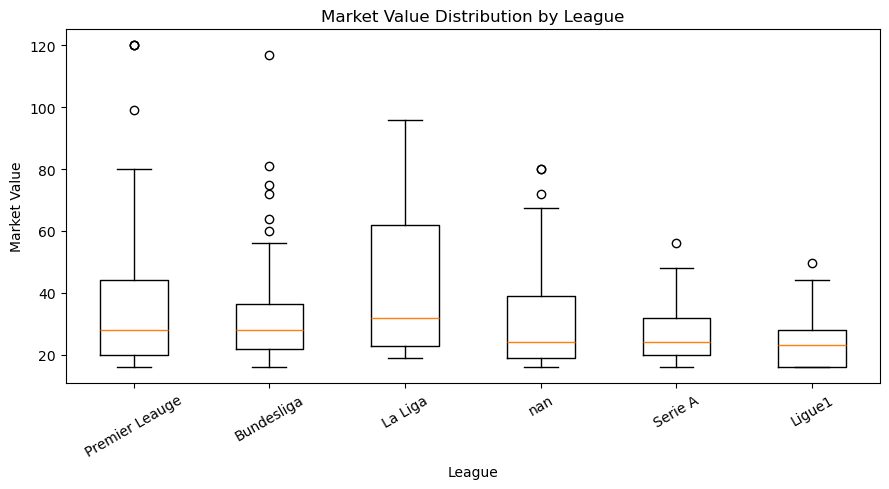

In [30]:
league_order = df["league"].dropna().unique()
data_to_plot = [df[df["league"] == league]["market value"].dropna() for league in league_order]

plt.figure(figsize=(9, 5))
plt.boxplot(data_to_plot, tick_labels=league_order)
plt.xlabel("League")
plt.ylabel("Market Value")
plt.title("Market Value Distribution by League")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [31]:
from scipy.stats import pearsonr

df_age = df.dropna(subset=["age_x", "market value"]).copy()

corr, p_value = pearsonr(df_age["age_x"], df_age["market value"])

print("Sample size:", len(df_age))
print("Correlation coefficient:", corr)
print("p-value:", p_value)

Sample size: 196
Correlation coefficient: 0.10893539948439737
p-value: 0.1285443497449124


In [32]:
from scipy.stats import pearsonr

df_goals = df.dropna(subset=["gls", "market value"]).copy()

corr, p_value = pearsonr(df_goals["gls"], df_goals["market value"])

print("Sample size:", len(df_goals))
print("Correlation coefficient:", corr)
print("p-value:", p_value)

Sample size: 194
Correlation coefficient: 0.4219245747808896
p-value: 8.940512612578414e-10


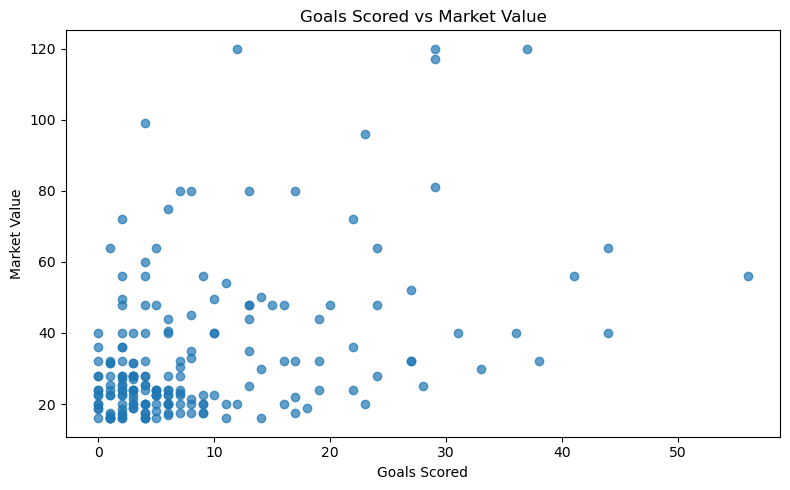

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df_goals["gls"], df_goals["market value"], alpha=0.7)
plt.xlabel("Goals Scored")
plt.ylabel("Market Value")
plt.title("Goals Scored vs Market Value")
plt.tight_layout()
plt.show()